# RAG Evaluation Metrics — Exploration

Loads the latest Langfuse export from `local/metric-export/` and produces basic plots.

**Run the export first:**
```bash
python analysis/langfuse_export.py --session-id <your_session_id>
```

In [9]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

EXPORT_DIR = Path("../local/metric-export")


def load_latest(prefix: str = "*langfuse_export*") -> pd.DataFrame:
    files = sorted(EXPORT_DIR.glob(f"{prefix}.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files matching {EXPORT_DIR / prefix}")
    path = files[-1]
    print(f"Loading: {path.name}")
    return pd.read_parquet(path)


df = load_latest(prefix="2026-03-04_18-34_langfuse_export_multilingual-e5-small_q4__ministral_3_3B_q4")
print(f"Shape: {df.shape}")
df.head()

Loading: 2026-03-04_18-34_langfuse_export_multilingual-e5-small_q4__ministral_3_3B_q4.parquet
Shape: (132, 35)


,trace_id,session_id,observation_id,start_time,end_time,latency_ms,run_id,claim_id,langfuse_observation_type,latency_ttft_ms,...,metrics_precision_at_k,metrics_mrr,latency_e2e_latency_ms,hardware_max_ram_usage_mb,hardware_avg_cpu_utilization_pct,hardware_swap_in_bytes,hardware_swap_out_bytes,score_Correctness,score_Context Recall,score_Evaluate Hallucination V2
0,fe0589f980ec26becbb625f59add0856,multilingual-e5-small_q4__ministral_3_3B_q4,49c7977164bd51f6,2026-03-04 17:50:49.379000+00:00,2026-03-04 17:50:50.672000+00:00,1293.0,multilingual-e5-small_q4__ministral_3_3B_q4,emanual_92,generation,292.566306,...,0.000000,0.000000,1290.621000,7336.578125,19.35,10895360,0,0.10,1.000000e+00,0.0
1,e1b85b669f0c2b0cb92b1f739ce734b2,multilingual-e5-small_q4__ministral_3_3B_q4,7b4f2ef379efe3e1,2026-03-04 17:50:48.819000+00:00,2026-03-04 17:50:49.379000+00:00,560.0,multilingual-e5-small_q4__ministral_3_3B_q4,emanual_403,generation,47.638400,...,0.166667,0.200000,555.620458,7332.531250,0.00,2834432,0,0.15,1.000000e+00,0.1
2,e065ebcd0b5659733b767cb42517baa9,multilingual-e5-small_q4__ministral_3_3B_q4,9509de51d58d7e2d,2026-03-04 17:50:46.380000+00:00,2026-03-04 17:50:48.819000+00:00,2439.0,multilingual-e5-small_q4__ministral_3_3B_q4,emanual_276,generation,61.229333,...,0.166667,0.333333,2429.335458,7261.703125,24.00,5210112,32768,0.55,4.000000e-16,0.3
3,5397901369dfeeea7f9cd6835794f9e2,multilingual-e5-small_q4__ministral_3_3B_q4,4ffb396628a33612,2026-03-04 17:50:44.434000+00:00,2026-03-04 17:50:46.380000+00:00,1946.0,multilingual-e5-small_q4__ministral_3_3B_q4,emanual_347,generation,1199.352086,...,0.500000,1.000000,1939.026125,7267.968750,17.75,9617408,0,0.60,1.000000e+00,0.1
4,9e28501ef1075dac7f2e459518aade8f,multilingual-e5-small_q4__ministral_3_3B_q4,ff5fc5a78e05abf1,2026-03-04 17:50:42.873000+00:00,2026-03-04 17:50:44.433000+00:00,1560.0,multilingual-e5-small_q4__ministral_3_3B_q4,emanual_82,generation,46.480755,...,0.000000,0.000000,1548.347625,7374.234375,16.75,4096000,32768,0.10,1.000000e+00,0.0


## Summary statistics

In [23]:
metric_cols = [
    c for c in df.columns
    if any(c.startswith(p) for p in ("metrics_", "latency_", "generation_", "hardware_", "score_"))
]
df[metric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
latency_ms,132.0,2.558652e+03,8.966562e+03,324.000000,1.229250e+03,1.660000e+03,2.176750e+03,1.043320e+05
latency_ttft_ms,132.0,1.210165e+03,8.693449e+03,42.120667,5.624876e+01,3.754820e+02,6.590337e+02,1.002313e+05
latency_llm_generation_latency_ms,132.0,1.051340e+03,7.330863e+02,41.219000,5.266825e+02,9.561970e+02,1.348916e+03,4.303322e+03
latency_prompt_ms,132.0,1.188631e+03,8.689096e+03,24.634000,3.479800e+01,3.529425e+02,6.354830e+02,1.001604e+05
latency_predicted_ms,132.0,1.051340e+03,7.330863e+02,41.219000,5.266825e+02,9.561970e+02,1.348916e+03,4.303322e+03
latency_predicted_per_token_ms,132.0,2.153413e+01,4.916755e+00,13.739667,2.051523e+01,2.100609e+01,2.192542e+01,7.091137e+01
generation_prompt_tokens,132.0,3.411515e+02,1.398395e+02,200.000000,2.310000e+02,2.895000e+02,4.080000e+02,7.340000e+02
generation_completion_tokens,132.0,4.737121e+01,3.044916e+01,3.000000,2.550000e+01,4.600000e+01,6.200000e+01,2.000000e+02
generation_tokens_per_second,132.0,4.760949e+01,6.426036e+00,14.102111,4.560916e+01,4.760549e+01,4.874428e+01,7.278197e+01
latency_retrieval_latency_ms,132.0,6.258261e+01,5.129328e+01,7.469875,1.894054e+01,4.295844e+01,9.814694e+01,2.509171e+02


## Latency distribution

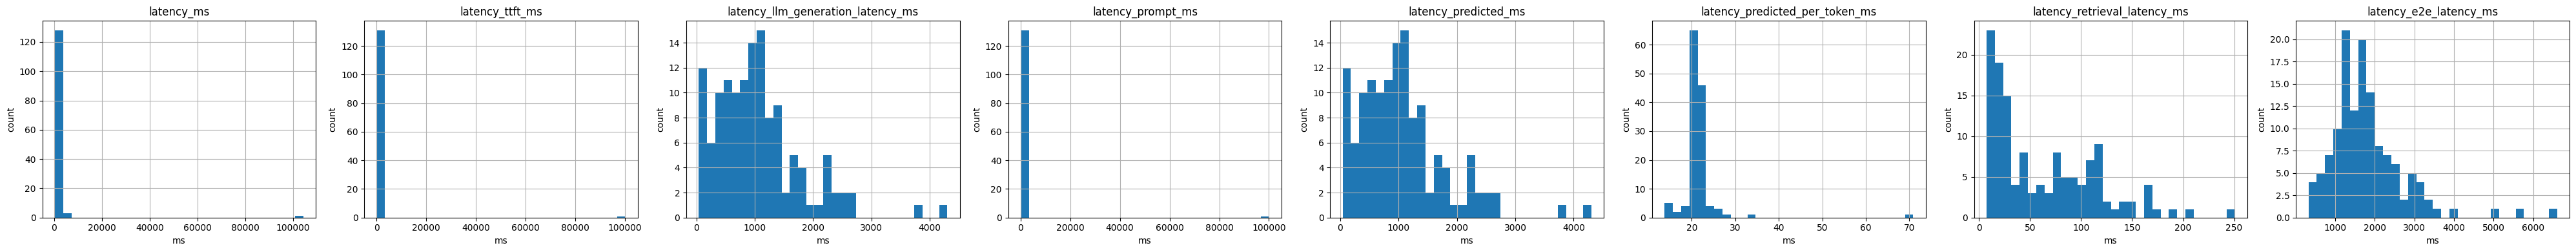

In [28]:
latency_cols = [c for c in df.columns if "latency" in c]

fig, axes = plt.subplots(1, len(latency_cols), figsize=(5*len(latency_cols), 4))
if len(latency_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, latency_cols):
    df[col].dropna().hist(bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("ms")
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

## Retrieval quality: Recall vs MRR

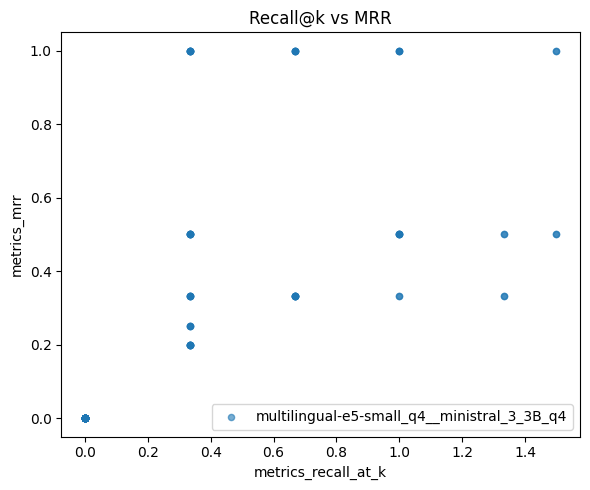

In [29]:
recall_col = next((c for c in df.columns if "recall" in c), None)
mrr_col = next((c for c in df.columns if "mrr" in c), None)

if recall_col and mrr_col:
    fig, ax = plt.subplots(figsize=(6, 5))
    groups = df.groupby("run_id") if "run_id" in df.columns else [("all", df)]
    for label, group in groups:
        ax.scatter(group[recall_col], group[mrr_col], label=label, alpha=0.6, s=20)
    ax.set_xlabel(recall_col)
    ax.set_ylabel(mrr_col)
    ax.set_title("Recall@k vs MRR")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("recall or mrr columns not found — skipping scatter plot")

## Langfuse scores (if present)

,count,mean,std,min,25%,50%,75%,max
score_Correctness,132.0,0.301515,0.295574,0.0,0.1,0.2,0.5,1.0
score_Context Recall,132.0,1.491667,4.413101,0.0,1.0,1.0,1.0,50.0
score_Evaluate Hallucination V2,132.0,0.173030,0.295728,0.0,0.0,0.0,0.2,1.0


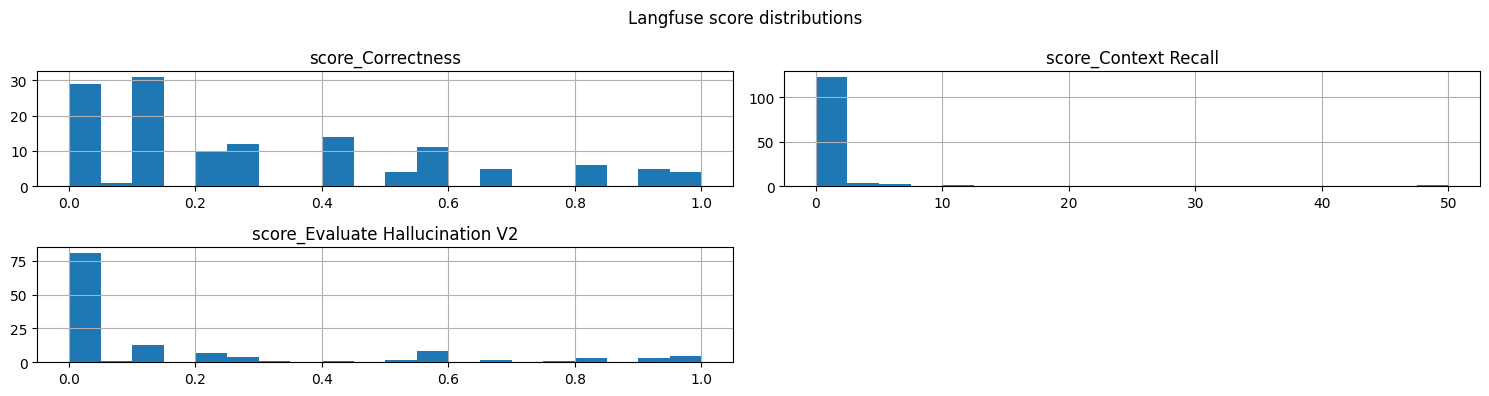

In [30]:
score_cols = [c for c in df.columns if c.startswith("score_")]
if score_cols:
    display(df[score_cols].describe().T)
    df[score_cols].hist(bins=20, figsize=(5 * len(score_cols), 4))
    plt.suptitle("Langfuse score distributions")
    plt.tight_layout()
    plt.show()
else:
    print("No score_ columns found — no Langfuse scores were exported")

## Generation throughput

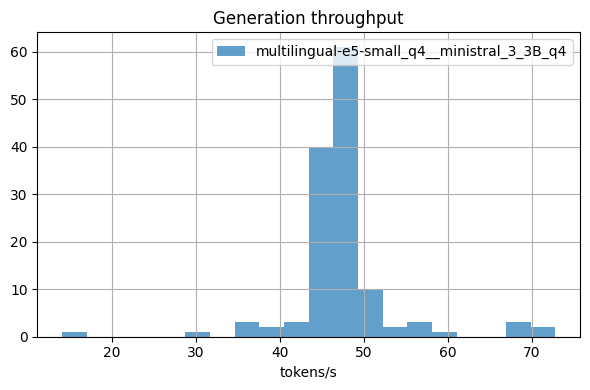

In [31]:
tps_col = next((c for c in df.columns if "tokens_per_second" in c), None)
if tps_col:
    fig, ax = plt.subplots(figsize=(6, 4))
    if "run_id" in df.columns:
        for label, group in df.groupby("run_id"):
            group[tps_col].dropna().hist(bins=20, ax=ax, alpha=0.7, label=label)
        ax.legend()
    else:
        df[tps_col].dropna().hist(bins=20, ax=ax)
    ax.set_xlabel("tokens/s")
    ax.set_title("Generation throughput")
    plt.tight_layout()
    plt.show()

# Compare Multiple Runs

In [14]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

EXPORT_DIR = Path("../local/metric-export")

def load_files(
    paths: list[str | Path] | None = None,
    folder: str | Path | None = None,
    pattern: str = "*langfuse_export*.parquet",
) -> pd.DataFrame:
    """Load one or more parquet export files into a single DataFrame.

    Args:
        paths:   explicit list of file paths to load.
        folder:  directory to glob all matching files from (uses `pattern`).
        pattern: glob pattern applied when `folder` is given.

    At least one of `paths` or `folder` must be provided.
    When both are given they are combined.
    """
    if paths is None and folder is None:
        raise ValueError("Provide at least one of `paths` or `folder`.")

    resolved: list[Path] = []

    if paths:
        resolved += [Path(p) for p in paths]

    if folder:
        matched = sorted(Path(folder).glob(pattern))
        if not matched:
            raise FileNotFoundError(f"No files matching '{pattern}' in {folder}")
        resolved += matched

    if not resolved:
        raise FileNotFoundError("No files found to load.")

    frames = []
    for p in resolved:
        print(f"Loading: {p.name}")
        frames.append(pd.read_parquet(p))

    df_all = pd.concat(frames, ignore_index=True)
    print(f"\nTotal shape: {df_all.shape}")
    return df_all


# Examples:
# Load every export in the default directory:
df_multiple = load_files(folder=EXPORT_DIR)
metric_cols = [
    c for c in df_multiple.columns
    if any(c.startswith(p) for p in ("metrics_", "latency_", "generation_", "hardware_", "score_"))
]
#
# Load specific files:
#   df = load_files(paths=["../local/metric-export/run_a.parquet",
#                          "../local/metric-export/run_b.parquet"])
#
# Mix both:
#   df = load_files(paths=["../local/metric-export/run_a.parquet"], folder=EXPORT_DIR)


Loading: 2026-03-04_18-34_langfuse_export_multilingual-e5-small_q4__ministral_3_3B_q4.parquet
Loading: 2026-03-04_21-08_langfuse_export_ministral_3_3B_q5.parquet
Loading: 2026-03-04_21-13_langfuse_export_ministral_3_3B_q8.parquet
Loading: 2026-03-04_21-15_langfuse_export_ministral_3_8B_q4.parquet
Loading: 2026-03-04_21-17_langfuse_export_ministral_3_8B_q5.parquet

Total shape: (660, 35)


In [15]:
def plot_boxplot(
    df: pd.DataFrame,
    col: str,
    session_order: list[str] | None = None,
    ax=None,
    figsize: tuple[int, int] = (10, 5),
) -> None:
    """Box plot for one numeric column, one box per session_id.

    Args:
        df:            DataFrame with a `session_id` column.
        col:           Numeric column to plot.
        session_order: Explicit order of session_ids on the x-axis.
                       Defaults to alphabetical order.
        ax:            Existing matplotlib Axes to draw on (for embedding in
                       a multi-panel figure). Creates a new figure when None.
        figsize:       Figure size when creating a standalone figure.
    """
    sessions = session_order or sorted(df["session_id"].dropna().unique())
    data = [df.loc[df["session_id"] == s, col].dropna().values for s in sessions]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)

    ax.boxplot(data, tick_labels=sessions, vert=True)
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.set_xticklabels(sessions, rotation=45, ha="right")

    if standalone:
        plt.tight_layout()
        plt.show()


def plot_boxplots(
    df: pd.DataFrame,
    cols: list[str],
    session_order: list[str] | None = None,
    figsize: tuple[int, int] | None = None,
) -> None:
    """Box plots for multiple numeric columns, rendered side by side.

    Args:
        df:            DataFrame with a `session_id` column.
        cols:          List of numeric columns to plot, one subplot each.
        session_order: Explicit order of session_ids on every x-axis.
                       Defaults to alphabetical order.
        figsize:       Overall figure size. Defaults to (4 * len(cols), 5).
    """
    n = len(cols)
    if figsize is None:
        figsize = (max(6, 4 * n), 5)

    fig, axes = plt.subplots(1, n, figsize=figsize, sharey=False)
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, cols):
        plot_boxplot(df, col, session_order=session_order, ax=ax)

    plt.tight_layout()
    plt.show()


# --- Examples ---
# Single column:
#   plot_boxplot(df, "metrics_mrr")
#
# Single column with explicit session order:
#   plot_boxplot(df, "latency_e2e_latency_ms",
#                session_order=["run_a", "run_b", "run_c"])
#
# Multiple columns side by side:
#   plot_boxplots(df, ["metrics_recall_at_k", "metrics_mrr", "score_Correctness"],
#                 session_order=["run_a", "run_b"])

In [16]:
# df_multiple.loc[df_multiple["score_Context Recall"] > 1.0, "score_Context Recall"] = 1.0

In [17]:
if "run_id" in df_multiple.columns:
    agg_cols = [c for c in metric_cols if df_multiple[c].dtype in ("float64", "float32", "int64")]
    display(df_multiple.groupby("run_id")[agg_cols].mean().round(3))

,latency_ms,latency_ttft_ms,latency_llm_generation_latency_ms,latency_prompt_ms,latency_predicted_ms,latency_predicted_per_token_ms,generation_prompt_tokens,generation_completion_tokens,generation_tokens_per_second,latency_retrieval_latency_ms,...,metrics_precision_at_k,metrics_mrr,latency_e2e_latency_ms,hardware_max_ram_usage_mb,hardware_avg_cpu_utilization_pct,hardware_swap_in_bytes,hardware_swap_out_bytes,score_Correctness,score_Context Recall,score_Evaluate Hallucination V2
run_id,,,,,,,,,,,,,,,,,,,,,
ministral_3_3B_q5,1599.129,466.602,1071.950,441.755,1071.950,24.846,341.152,42.273,40.501,24.407,...,0.149,0.285,1594.200,7812.776,16.176,2.291712e+07,106868.364,0.264,1.239,0.196
ministral_3_3B_q8,1551.652,404.290,1052.604,378.722,1052.604,25.568,341.152,40.030,39.433,34.431,...,0.149,0.285,1543.593,8671.682,18.573,3.825155e+07,100165.818,0.274,1.168,0.133
ministral_3_8B_q4,3416.629,1033.715,2088.311,989.913,2088.311,43.802,341.152,47.212,22.838,81.260,...,0.149,0.285,3401.040,9680.455,17.663,9.461338e+07,511007.030,0.319,1.582,0.119
ministral_3_8B_q5,4326.652,1168.237,2524.117,1114.747,2524.117,53.491,341.152,46.659,18.707,94.312,...,0.149,0.285,4303.351,10289.195,20.219,1.225433e+08,446836.364,0.341,2.114,0.122
multilingual-e5-small_q4__ministral_3_3B_q4,2558.652,1210.165,1051.340,1188.631,1051.340,21.534,341.152,47.371,47.609,62.583,...,0.149,0.285,1799.559,7548.400,26.713,3.706520e+07,291684.848,0.302,1.492,0.173


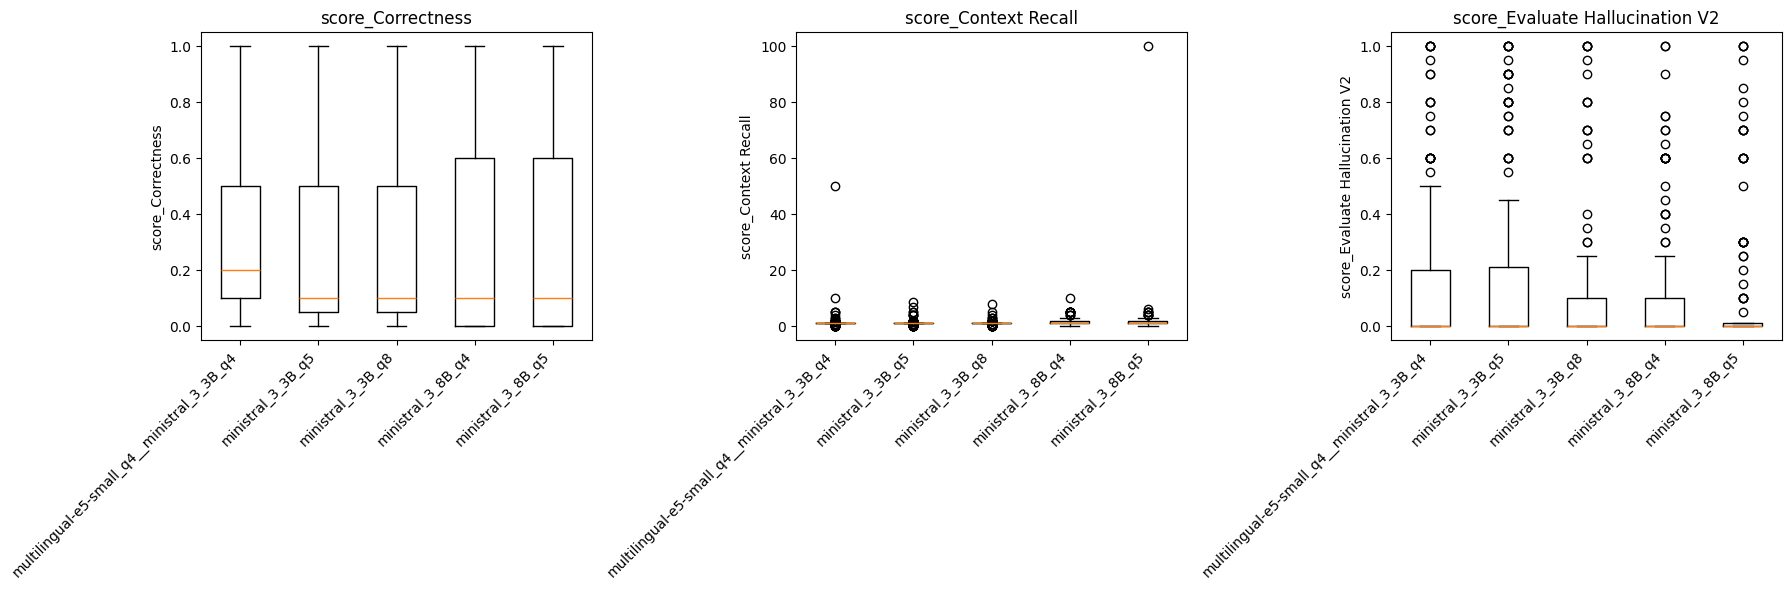

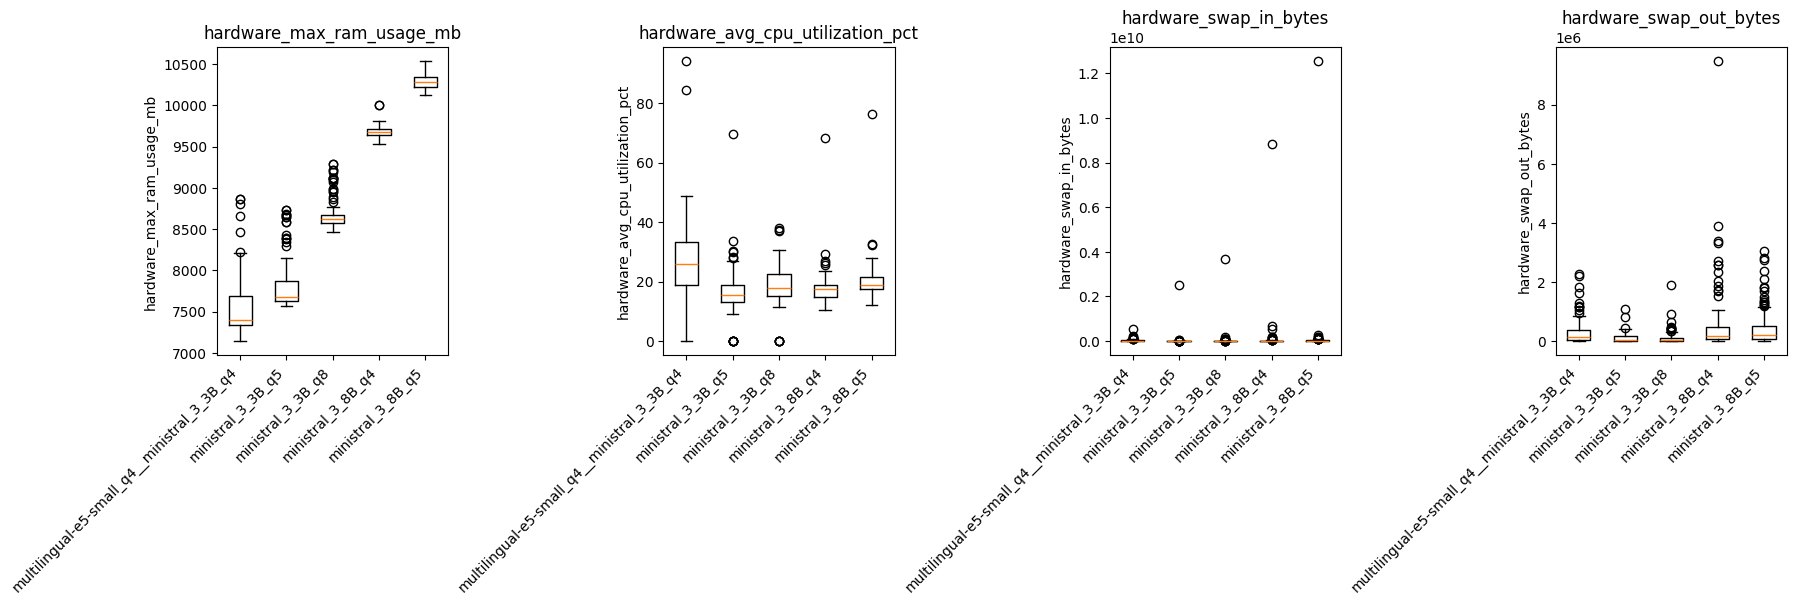

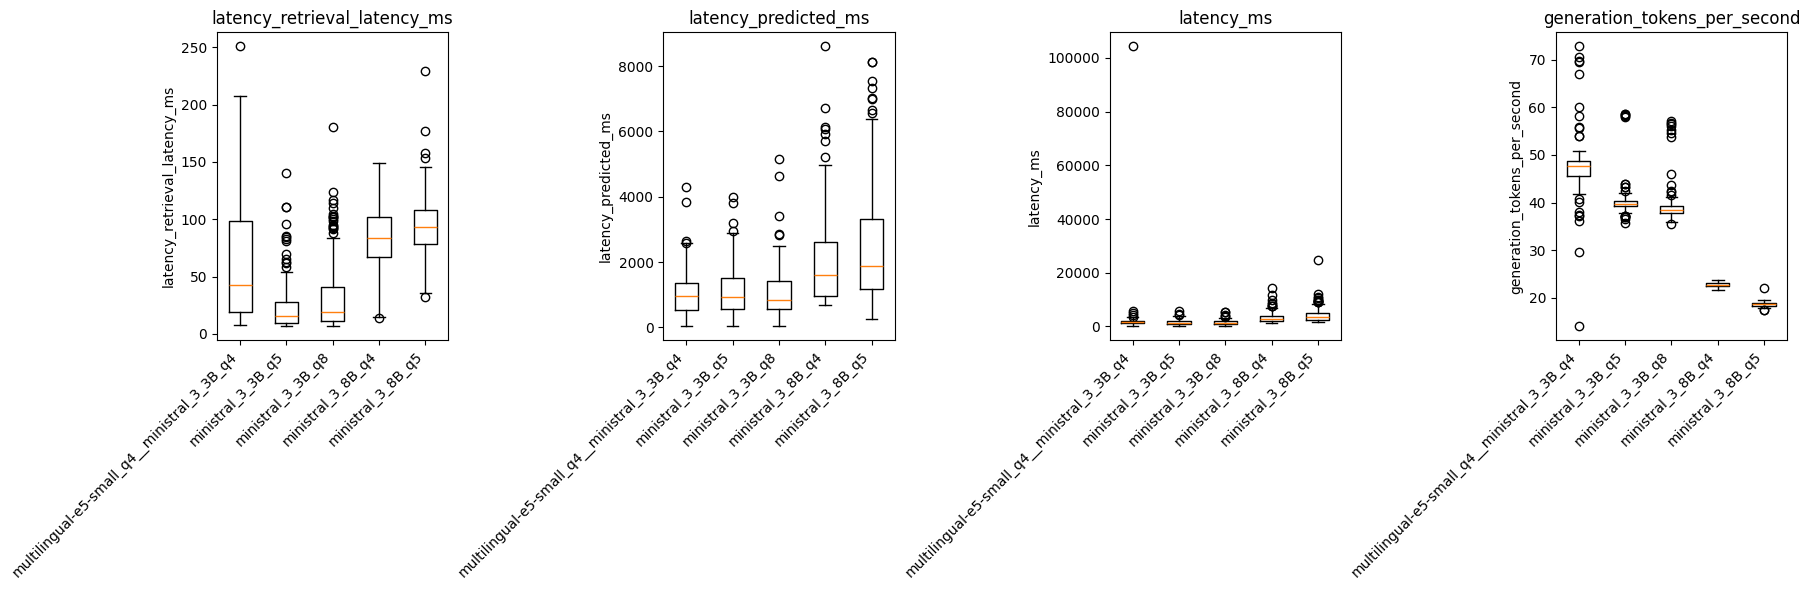

In [18]:
session_order=["multilingual-e5-small_q4__ministral_3_3B_q4", "ministral_3_3B_q5", "ministral_3_3B_q8", "ministral_3_8B_q4", "ministral_3_8B_q5"]

plot_boxplots(df_multiple, ["score_Correctness", "score_Context Recall", "score_Evaluate Hallucination V2"],
              session_order=session_order, figsize=(18,6))


plot_boxplots(df_multiple, ["hardware_max_ram_usage_mb", "hardware_avg_cpu_utilization_pct", "hardware_swap_in_bytes", "hardware_swap_out_bytes"],
              session_order=session_order, figsize=(18,6))

plot_boxplots(df_multiple, ["latency_retrieval_latency_ms", "latency_predicted_ms", "latency_ms", "generation_tokens_per_second"],
              session_order=session_order, figsize=(18,6))

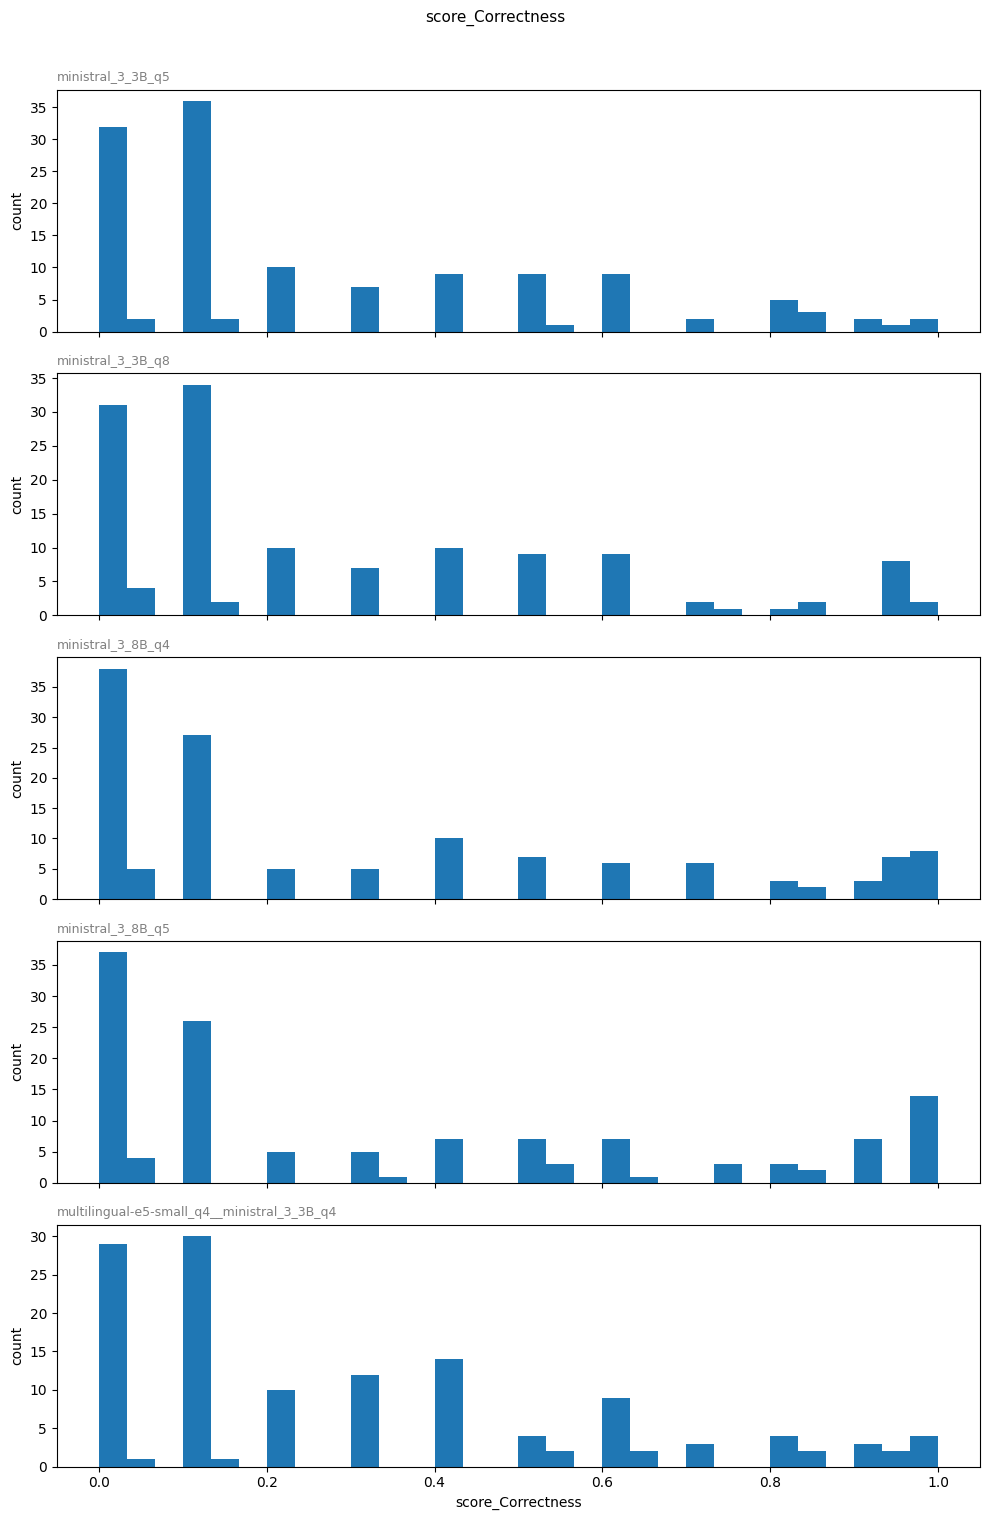

In [19]:
def plot_histograms_by_session(
    df: pd.DataFrame,
    col: str,
    session_order: list[str] | None = None,
    bins: int = 30,
    figsize_per_row: tuple[int, int] = (10, 3),
) -> None:
    """One histogram row per session_id, all sharing the same x-axis.

    Args:
        df:              DataFrame with a `session_id` column.
        col:             Numeric column to plot.
        session_order:   Explicit top-to-bottom order of session_ids.
                         Defaults to alphabetical order.
        bins:            Number of histogram bins.
        figsize_per_row: (width, height) per subplot row.
    """
    sessions = session_order or sorted(df["session_id"].dropna().unique())
    n = len(sessions)
    fig, axes = plt.subplots(
        n, 1,
        figsize=(figsize_per_row[0], figsize_per_row[1] * n),
        sharex=True,
    )
    if n == 1:
        axes = [axes]

    for ax, session in zip(axes, sessions):
        data = df.loc[df["session_id"] == session, col].dropna()
        ax.hist(data, bins=bins)
        ax.set_ylabel("count")
        ax.set_title(session, loc="left", fontsize=9, color="grey")

    axes[-1].set_xlabel(col)
    fig.suptitle(col, fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()


# Example:
#   plot_histograms_by_session(df, "latency_e2e_latency_ms")
plot_histograms_by_session(df_multiple, "score_Correctness")
